# Multi-Agent RL: Cooperative and Competitive Agents

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand multi-agent RL concepts
- Implement multi-agent environments
- Train cooperative agents
- Train competitive agents
- Compare multi-agent approaches

## 🔗 Prerequisites

- ✅ Understanding of single-agent RL
- ✅ Understanding of policies and value functions
- ✅ Python, NumPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Implementing multi-agent RL environments and training cooperative/competitive agents

---

## Introduction

**Multi-agent RL** involves multiple agents learning and interacting in the same environment, either cooperatively (shared goals) or competitively (conflicting goals).

## Lesson Brief

This lesson introduces environments where more than one agent is learning at the same time.

Students will see how cooperation and competition create new difficulties that do not exist in single-agent RL.

Why this matters: many real systems involve multiple decision-makers, not only one isolated learner.

This lesson helps students understand why multi-agent environments feel less stable.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Can AI Learn to Cooperate? Multi Agent Deep Deterministic Policy Gradients (MADDPG) in PyTorch"**:
[Watch on YouTube](https://www.youtube.com/watch?v=tZTQ6S9PfkE)

Why this pick:
- focused treatment of cooperative and competitive multi-agent learning.
- Explains why multi-agent settings are harder than single-agent RL.
- Helpful for students seeing centralized training and decentralized behavior ideas for the first time.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Cooperative setting: agents help each other.
- Competitive setting: one agent can hurt another.
- Coordination: aligning actions.
- Non-stationarity: the world changes because other agents act too.
- Credit assignment: deciding which agent deserves reward or blame.

### Quick Check
- How is multi-agent RL different from single-agent RL?
- What changes between cooperation and competition?
- Why can the environment feel unstable to one agent?
- Why is assigning credit harder when many agents contribute?

### Common Mistakes
- Assuming other agents are fixed.
- Ignoring coordination failures.
- Treating cooperation and competition as small details.
- Forgetting that learning becomes harder because each agent changes the training environment for the others.


## Why Multi-Agent RL Feels Harder Than Single-Agent RL

In single-agent RL, the environment may already be difficult, but at least the agent is usually not competing with other changing learners.

### The key difficulty

In multi-agent RL, each learner changes the world seen by the others.
That means the environment can feel non-stationary even if the external rules stay the same.

### Cooperation versus competition

- In **cooperation**, the difficulty is often coordination and shared credit.
- In **competition**, the difficulty is often adaptation, strategy, and opponent response.

### Teaching takeaway

Students should not think multi-agent RL is only "single-agent RL plus more people."
It changes the nature of the learning problem itself.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nMulti-Agent RL: Cooperative and Competitive Agents")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nMulti-Agent RL Types:")
# Show text or numbers in the cell output area under the code.
print("  - Cooperative: Agents share rewards, work toward common goal")
# Show text or numbers in the cell output area under the code.
print("  - Competitive: Agents have conflicting goals (zero-sum)")
# Show text or numbers in the cell output area under the code.
print("  - Mixed: Combination of cooperation and competition")

# Show text or numbers in the cell output area under the code.
print("\nKey Challenges:")
# Show text or numbers in the cell output area under the code.
print("  - Non-stationary environment (other agents learn)")
# Show text or numbers in the cell output area under the code.
print("  - Credit assignment (who gets credit)")
# Show text or numbers in the cell output area under the code.
print("  - Coordination (communicating/coordinating actions)")
# Show text or numbers in the cell output area under the code.
print("  - Scalability (many agents)")

# Show text or numbers in the cell output area under the code.
print("\n✅ Multi-agent RL concepts understood!")


✅ Libraries imported!

Multi-Agent RL: Cooperative and Competitive Agents

Multi-Agent RL Types:
  - Cooperative: Agents share rewards, work toward common goal
  - Competitive: Agents have conflicting goals (zero-sum)
  - Mixed: Combination of cooperation and competition

Key Challenges:
  - Non-stationary environment (other agents learn)
  - Credit assignment (who gets credit)
  - Coordination (communicating/coordinating actions)
  - Scalability (many agents)

✅ Multi-agent RL concepts understood!


## 🌍 Real-World Worked Example — Competitive Multi-Agent with Independent Q-Learning

**Industry context:**
- Waymo simulates thousands of autonomous vehicles (agents) sharing the same road
- Google DeepMind's AlphaStar has 10 agents competing simultaneously in StarCraft II

We simulate a simple **2-agent grid competition** where two agents learn to navigate to goals while avoiding each other.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


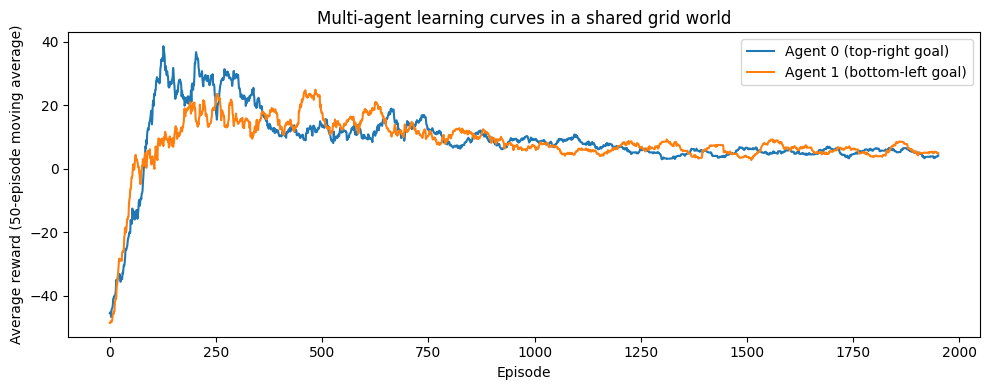


Final average rewards -> Agent 0: 4.6, Agent 1: 4.7

Teaching point:
Each agent learns while the other agent is also changing, which makes the
environment non-stationary from any single agent's perspective.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
GRID = 5
# Another assignment—same idea: store a value for the lines below.
N_ACTIONS = 4
# Another assignment—same idea: store a value for the lines below.
DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]


# Function `state_to_idx` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: r, c.
def state_to_idx(r, c):
    # Send a value back to whoever called this function.
    return r * GRID + c


# Function `step_agent` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: pos, action.
def step_agent(pos, action):
    # Save a value in a name so the next lines can read it.
    dr, dc = DELTAS[action]
    # Send a value back to whoever called this function.
    return (max(0, min(GRID - 1, pos[0] + dr)), max(0, min(GRID - 1, pos[1] + dc)))


# Save a value in a name so the next lines can read it.
GOALS = [(0, GRID - 1), (GRID - 1, 0)]
# Another assignment—same idea: store a value for the lines below.
Q = [np.zeros((GRID * GRID, N_ACTIONS)) for _ in range(2)]
# Another assignment—same idea: store a value for the lines below.
alpha = 0.1
# Another assignment—same idea: store a value for the lines below.
gamma = 0.95
# Another assignment—same idea: store a value for the lines below.
eps = 1.0
# Another assignment—same idea: store a value for the lines below.
eps_decay = 0.998
# Unpack the one-step model output from transition(state, action).
rewards_hist = [[], []]

# Start a loop: repeat the indented block once per item in the sequence.
for ep in range(2000):
    # Save a value in a name so the next lines can read it.
    pos = [(GRID - 1, 0), (0, GRID - 1)]
    # Another assignment—same idea: store a value for the lines below.
    ep_r = [0, 0]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(50):
        # Save a value in a name so the next lines can read it.
        actions = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for i in range(2):
            # Save a value in a name so the next lines can read it.
            s = state_to_idx(*pos[i])
            # Another assignment—same idea: store a value for the lines below.
            a = np.random.randint(N_ACTIONS) if np.random.rand() < eps else Q[i][s].argmax()
            # Add one new item to the end of a list (the list grows in place).
            actions.append(a)
        # Save a value in a name so the next lines can read it.
        new_pos = [step_agent(pos[i], actions[i]) for i in range(2)]
        # Start a loop: repeat the indented block once per item in the sequence.
        for i in range(2):
            # Save a value in a name so the next lines can read it.
            s = state_to_idx(*pos[i])
            # Another assignment—same idea: store a value for the lines below.
            s2 = state_to_idx(*new_pos[i])
            # Another assignment—same idea: store a value for the lines below.
            r = 10 if new_pos[i] == GOALS[i] else -1
            # Another assignment—same idea: store a value for the lines below.
            r -= 5 if new_pos[0] == new_pos[1] else 0
            # Another assignment—same idea: store a value for the lines below.
            Q[i][s, actions[i]] += alpha * (r + gamma * Q[i][s2].max() - Q[i][s, actions[i]])
            # Another assignment—same idea: store a value for the lines below.
            ep_r[i] += r
        # Another assignment—same idea: store a value for the lines below.
        pos = new_pos
        # If the condition is True, run the indented block under this line.
        if pos[0] == GOALS[0] and pos[1] == GOALS[1]:
            # Stop the loop completely and continue after the loop block.
            break
    # Start a loop: repeat the indented block once per item in the sequence.
    for i in range(2):
        # Add one new item to the end of a list (the list grows in place).
        rewards_hist[i].append(ep_r[i])
    # Save a value in a name so the next lines can read it.
    eps = max(eps * eps_decay, 0.05)

# Another assignment—same idea: store a value for the lines below.
ma0 = np.convolve(rewards_hist[0], np.ones(50) / 50, "valid")
# Another assignment—same idea: store a value for the lines below.
ma1 = np.convolve(rewards_hist[1], np.ones(50) / 50, "valid")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma0, label="Agent 0 (top-right goal)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma1, label="Agent 1 (bottom-left goal)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Multi-agent learning curves in a shared grid world")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Average reward (50-episode moving average)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print(
    # Build text with {…} holes filled in by variables (an f-string).
    f"\nFinal average rewards -> Agent 0: {np.mean(rewards_hist[0][-100:]):.1f}, "
    # Build text with {…} holes filled in by variables (an f-string).
    f"Agent 1: {np.mean(rewards_hist[1][-100:]):.1f}"
# Close the parentheses opened earlier (end this function call / grouping).
)
# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("Each agent learns while the other agent is also changing, which makes the")
# Show text or numbers in the cell output area under the code.
print("environment non-stationary from any single agent's perspective.")


In [ ]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Papers
- Lowe et al. (2017) — [Multi-Agent Actor-Critic (MADDPG)](https://arxiv.org/abs/1706.02275)
- OpenAI (2019) — [OpenAI Five: Dota2 with Multi-Agent RL](https://openai.com/five/)
- Vinyals et al. (2019) — [AlphaStar: StarCraft II](https://www.nature.com/articles/s41586-019-1724-z)

### State-of-the-art
- Waymo uses multi-agent simulation (many cars interacting) to train autonomous vehicles
- Uber's route optimisation treats every driver as an agent in a shared environment
"""))


## 📝 Summary

You explored **Multi-Agent Reinforcement Learning (MARL)** where multiple agents interact in shared environments. Independent Q-Learning is simple but can be unstable. Real applications: autonomous vehicles at intersections, trading algorithms, and multiplayer game AI.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


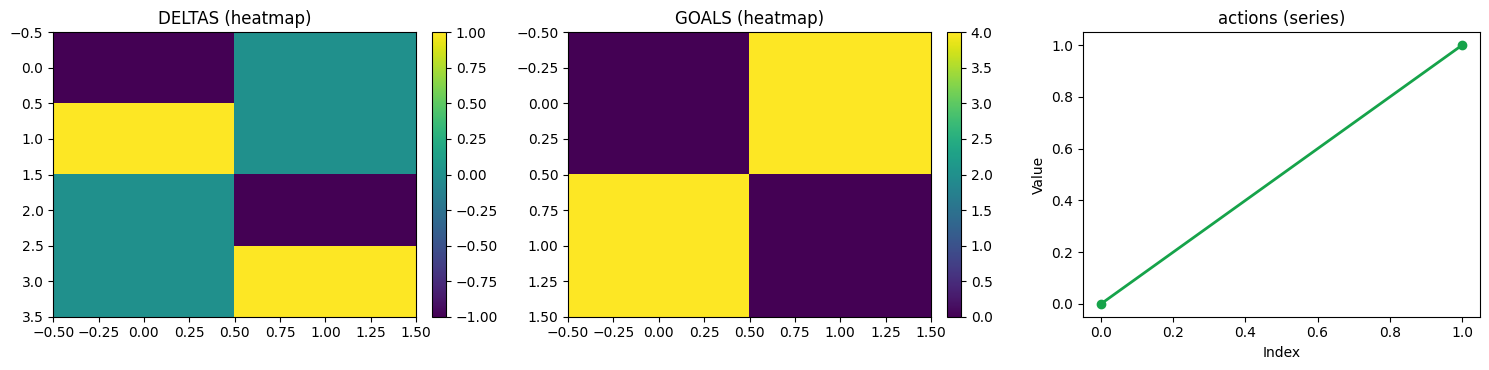

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Multi-agent RL becomes harder because each agent changes the environment seen by the others, creating non-stationarity.

**If students remember one idea:** When many learners act together, the world changes not only because of the environment but because the other learners keep adapting too.

**Quick check before moving on:**
- Can you explain why training becomes less stable when other agents are also learning?
- Can you describe the difference between cooperative and competitive multi-agent settings?

**Bridge to the next step:** Next, students will see how hierarchical structure can simplify long or complex tasks even in single-agent settings.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

This short **FrozenLake** rollout connects the ideas in this notebook to **motion on a grid**.
We use ``is_slippery=False`` so each step matches the tile you expect.

The policy here is **intentionally simple** (random actions): the goal is to **scrub timesteps**
with the slider and see how states evolve, not to claim this notebook's full algorithm is
already solved on this map.


In [ ]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")
